In [52]:
#Loadig data using pandas library
import pandas as pd
df = pd.read_csv('data/data.csv')
#View first rows
df.head()
#Understanding dataset
#Shows number of rows and columns
df.shape
# Shows the data types and missing values
df.info()
#Uderstanding data distrubution
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   size      10 non-null     int64
 1   bedrooms  10 non-null     int64
 2   age       10 non-null     int64
 3   price     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


Index(['size', 'bedrooms', 'age', 'price'], dtype='str')

In [53]:
#DATA CLEANING
#Checking missing values
print(df.isnull().sum())

size        0
bedrooms    0
age         0
price       0
dtype: int64


In [54]:
#Checking data types
df.dtypes

size        int64
bedrooms    int64
age         int64
price       int64
dtype: object

In [55]:
#DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df.corr()

,size,bedrooms,age,price
size,1.000000,0.946603,-0.907161,0.994466
bedrooms,0.946603,1.000000,-0.913580,0.949382
age,-0.907161,-0.913580,1.000000,-0.905800
price,0.994466,0.949382,-0.905800,1.000000


<Axes: >

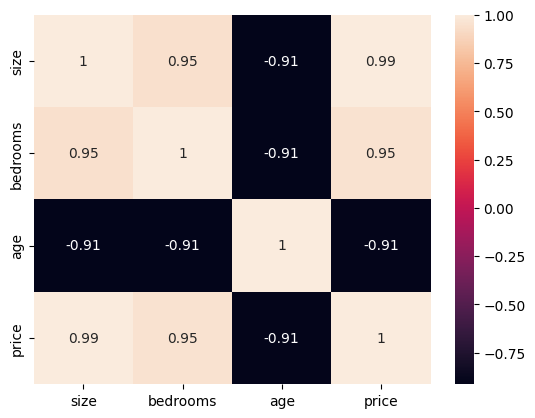

In [57]:
sns.heatmap(df.corr(), annot= True)

In [58]:
plt.show()

<Axes: xlabel='size', ylabel='price'>

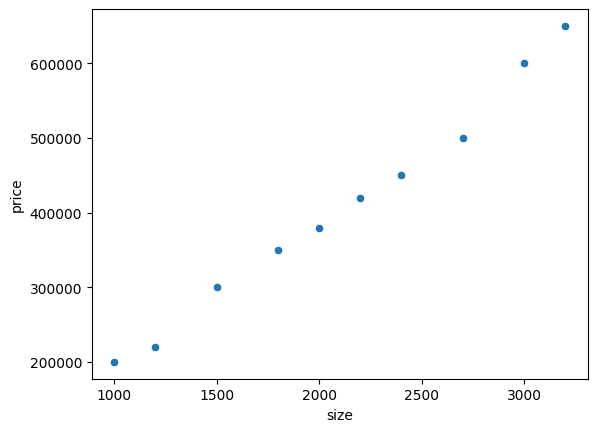

In [59]:
sns.scatterplot(x="size", y="price",  data=df)

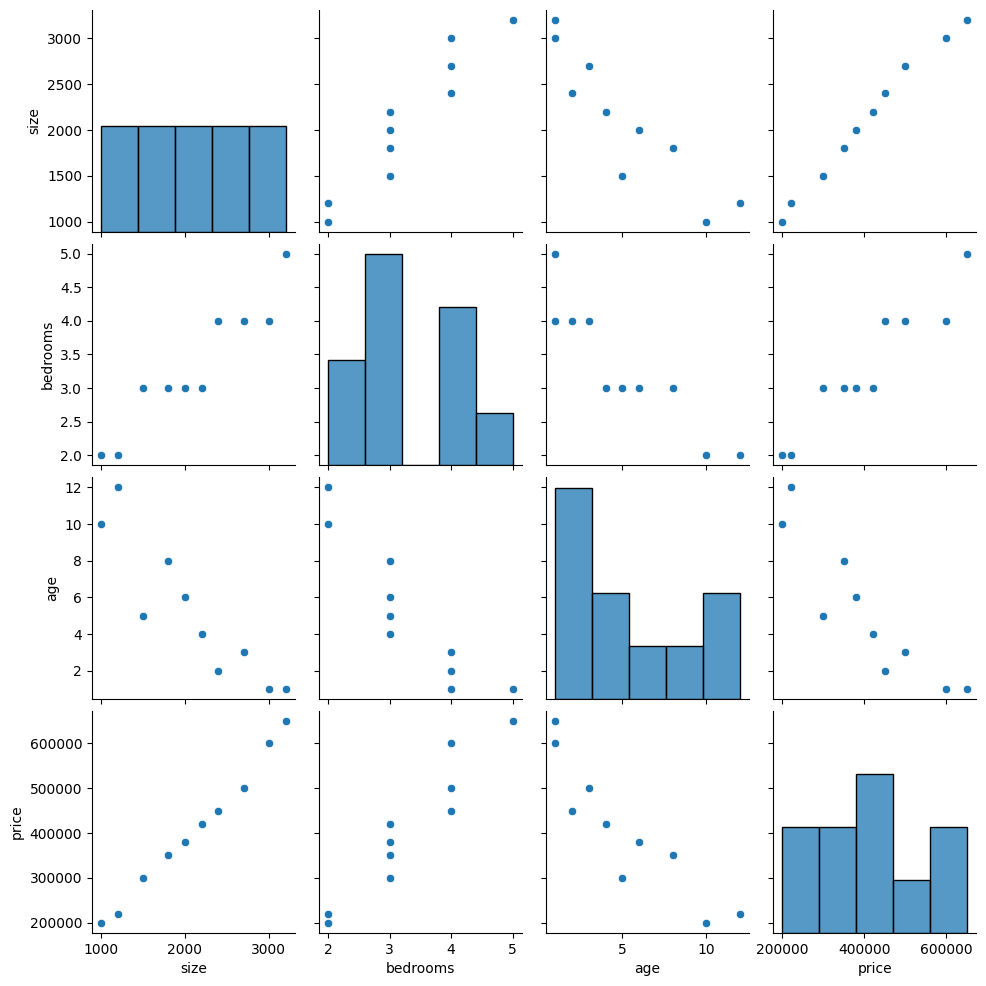

In [60]:
sns.pairplot(df)

<Axes: xlabel='size', ylabel='price'>

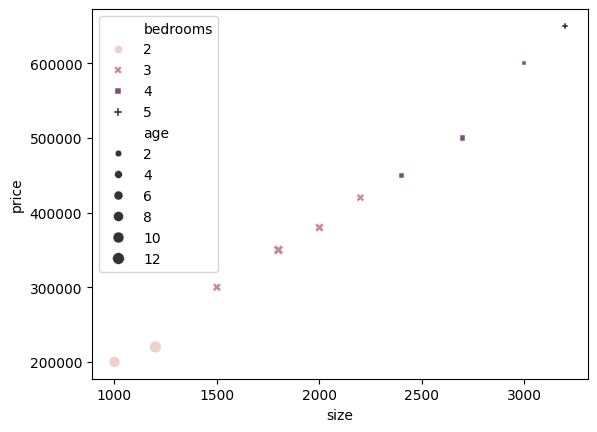

In [61]:
sns.scatterplot(x="size", y="price", data=df,
                hue="bedrooms",      # color
                size="age",          # marker size
                style="bedrooms")    # marker shape

In [62]:
#FEATURE SELECTION
X=df[['size', 'bedrooms', 'age']]
Y=df['price']

In [63]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.80, random_state=42)

In [64]:
#TRAIN MODEL using Linear Regression
from sklearn.linear_model import LinearRegression
lrm = LinearRegression()
lrm.fit(X_train, Y_train)
y_predict = lrm.predict(X_test)
print("y_predict : ", y_predict)


y_predict :  [534111.14670083 275395.57975657]


In [65]:
pd.DataFrame({'Y_test': Y_test, 'y_predict': y_predict})

,Y_test,y_predict
8,500000,534111.146701
1,300000,275395.579757


In [66]:
# Lower MSE = Better Model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_test, y_predict)
print("MSE:", mse)

MSE: 884473912.3806113


In [ ]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(Y_test, y_predict))
#1.0 → perfect model, 0.7–0.9 → good, 0.4–0.7 → average, <0.4 → weak model

R2 Score: 0.9115526087619389


In [67]:
#PREDICTION
new_house = [[2000, 3, 5]]
predicted_price = lrm.predict(new_house)

print("Predicted Price:", predicted_price)

Predicted Price: [383587.44394619]


c:\Users\hp\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
